# Realistic Loan Approval Dataset | US & Canada

Ce projet porte sur la modélisation du risque de crédit à partir d’un dataset réaliste intégrant des critères bancaires réels, permettant une analyse fiable des décisions d’octroi de prêts.

- Analyse exploratoire des données.

![Ma photo](img.png)

## Installation et importation des packages

In [1]:
# Install and import required packages

# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Data preprocessing
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils import resample
from sklearn.model_selection import cross_val_score

# Feature selection
from sklearn.feature_selection import RFECV
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Metrics and evaluation
from sklearn.metrics import (roc_auc_score, classification_report, 
                           confusion_matrix, roc_curve, auc, 
                           precision_recall_curve, f1_score)

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Importation de la dataset

In [2]:
import pandas as pd

df = pd.read_csv("data/Loan_approval_data.csv")
df.head()

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST129262,45,Self-Employed,21.9,40061,660,9.6,345,4168,0,0,0,Personal Loan,Home Improvement,45900,11.55,0.104,1.146,0.382,1
1,CUST121151,51,Employed,15.1,62071,662,26.7,2808,7937,0,0,0,Line of Credit,Personal,30100,10.27,0.128,0.485,0.162,1
2,CUST106607,37,Employed,13.8,15235,631,11.8,214,4615,0,0,0,Personal Loan,Personal,28300,14.03,0.303,1.858,0.619,1
3,CUST143202,53,Self-Employed,2.8,30466,807,23.8,7683,1014,0,0,0,Credit Card,Education,32700,15.96,0.033,1.073,0.358,1
4,CUST130173,40,Employed,9.4,60576,615,20.7,4695,9733,0,2,0,Line of Credit,Personal,36200,11.36,0.161,0.598,0.199,1


### Inspection initiale des données

In [3]:
df.shape

(50000, 20)

In [4]:
df.columns

Index(['customer_id', 'age', 'occupation_status', 'years_employed',
       'annual_income', 'credit_score', 'credit_history_years',
       'savings_assets', 'current_debt', 'defaults_on_file',
       'delinquencies_last_2yrs', 'derogatory_marks', 'product_type',
       'loan_intent', 'loan_amount', 'interest_rate', 'debt_to_income_ratio',
       'loan_to_income_ratio', 'payment_to_income_ratio', 'loan_status'],
      dtype='object')

In [5]:
df.describe()

,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,37.377600,8.594870,53330.570900,665.815140,9.544996,4507.478840,13395.706520,0.012800,0.375420,0.082220,32383.122000,14.951161,0.250877,0.639173,0.213051,0.890000
std,11.016651,8.002109,34750.598666,58.785653,7.447377,15009.954685,12160.555554,0.112412,0.651743,0.298633,26414.070625,4.070832,0.132104,0.445497,0.148505,0.312893
min,18.000000,0.000000,15000.000000,348.000000,0.000000,0.000000,64.000000,0.000000,0.000000,0.000000,500.000000,6.020000,0.002000,0.008000,0.003000,0.000000
25%,30.000000,1.900000,28968.750000,627.000000,3.100000,190.750000,5353.000000,0.000000,0.000000,0.000000,11200.000000,11.410000,0.149000,0.287000,0.096000,1.000000
50%,37.000000,6.300000,44325.000000,665.000000,8.000000,808.000000,9838.000000,0.000000,0.000000,0.000000,25100.000000,14.960000,0.238000,0.555000,0.185000,1.000000
75%,45.000000,13.200000,67507.000000,705.000000,14.500000,3000.000000,17393.000000,0.000000,1.000000,0.000000,47900.000000,18.340000,0.339000,0.909000,0.303000,1.000000
max,70.000000,39.900000,250000.000000,850.000000,30.000000,300000.000000,163344.000000,1.000000,7.000000,4.000000,100000.000000,23.000000,0.800000,2.001000,0.667000,1.000000


In [6]:
df.info()
# Check for missing values
print("\nMissing Values Count:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  object 
 1   age                      50000 non-null  int64  
 2   occupation_status        50000 non-null  object 
 3   years_employed           50000 non-null  float64
 4   annual_income            50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  int64  
 10  delinquencies_last_2yrs  50000 non-null  int64  
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  object 
 13  loan_intent              50000 non-null  object 
 14  loan_amount           

In [7]:
print("\nData Types:")
print(df.dtypes)
print("\nDescriptive stats:")
print(df.describe())

# Check for missing values
df.info()


Data Types:
customer_id                 object
age                          int64
occupation_status           object
years_employed             float64
annual_income                int64
credit_score                 int64
credit_history_years       float64
savings_assets               int64
current_debt                 int64
defaults_on_file             int64
delinquencies_last_2yrs      int64
derogatory_marks             int64
product_type                object
loan_intent                 object
loan_amount                  int64
interest_rate              float64
debt_to_income_ratio       float64
loan_to_income_ratio       float64
payment_to_income_ratio    float64
loan_status                  int64
dtype: object

Descriptive stats:
                age  years_employed  annual_income  credit_score  \
count  50000.000000    50000.000000   50000.000000  50000.000000   
mean      37.377600        8.594870   53330.570900    665.815140   
std       11.016651        8.002109   34750.59866

In [8]:
df = df.drop(columns=["customer_id"])
df = df.drop_duplicates()

Types de données :
 Le jeu de données comprend un mélange de variables numériques (entiers et décimales) et catégorielles (texte/objet), ainsi qu’une variable cible loan_status représentant le statut du prêt.

Statistiques descriptives : 
Ce tableau fournit un résumé statistique des variables numériques, incluant les mesures de tendance centrale (moyenne, médiane), de dispersion (écart-type) et d’étendue (minimum, maximum). Il permet de mieux comprendre la distribution de chaque variable quantitative.

Valeurs manquantes :
 L’analyse des données indique l’absence de valeurs manquantes dans les colonnes, ce qui constitue un avantage pour les étapes ultérieures de traitement et de modélisation.

### Analyse de la variable cible

#### Examen de la distribution de notre variable cible


Distribution de la variable cible (loan_status):


,Count,Percentage
loan_status,,
1,22026,80.018891
0,5500,19.981109


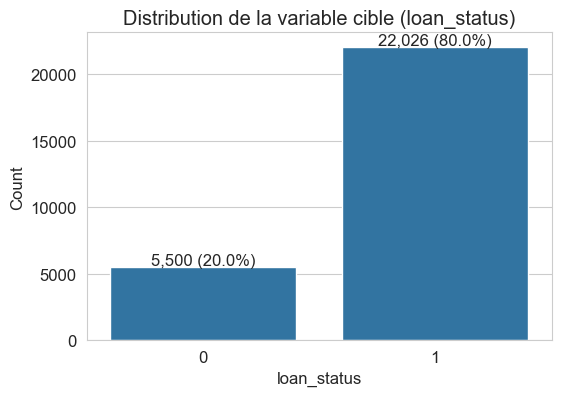

In [9]:
# Calculate loan_status statistics

default_counts = df['loan_status'].value_counts()
default_percent = df['loan_status'].value_counts(normalize=True) * 100
default_stats = pd.DataFrame({
    'Count': default_counts,
    'Percentage': default_percent
})
print("\nDistribution de la variable cible (loan_status):")
display(default_stats)

# Visualize distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='loan_status')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f} ({p.get_height()/len(df)*100:.1f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points')
plt.title('Distribution de la variable cible (loan_status)')
plt.ylabel('Count')
plt.show()

### Distribution de la variable cible (Default)


Déséquilibre des classes :
 La variable cible Default présente un déséquilibre entre les classes. 
Environ 80 % des prêts n’ont pas fait défaut (classe 0), tandis que 20 % correspondent à des défauts de paiement (classe 1).

Ce déséquilibre doit être pris en compte lors de l’entraînement et de l’évaluation des modèles, car il peut biaiser les performances (le modèle risque de favoriser la classe majoritaire). Des techniques comme le rééchantillonnage ou l’utilisation de métriques adaptées (ex : F1-score, AUC) peuvent être nécessaires.

### Analyse univariée

#### Étude des distributions des variables individuelles

In [10]:
# Numerical features
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('loan_status')  # Remove target variable

# Categorical features
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

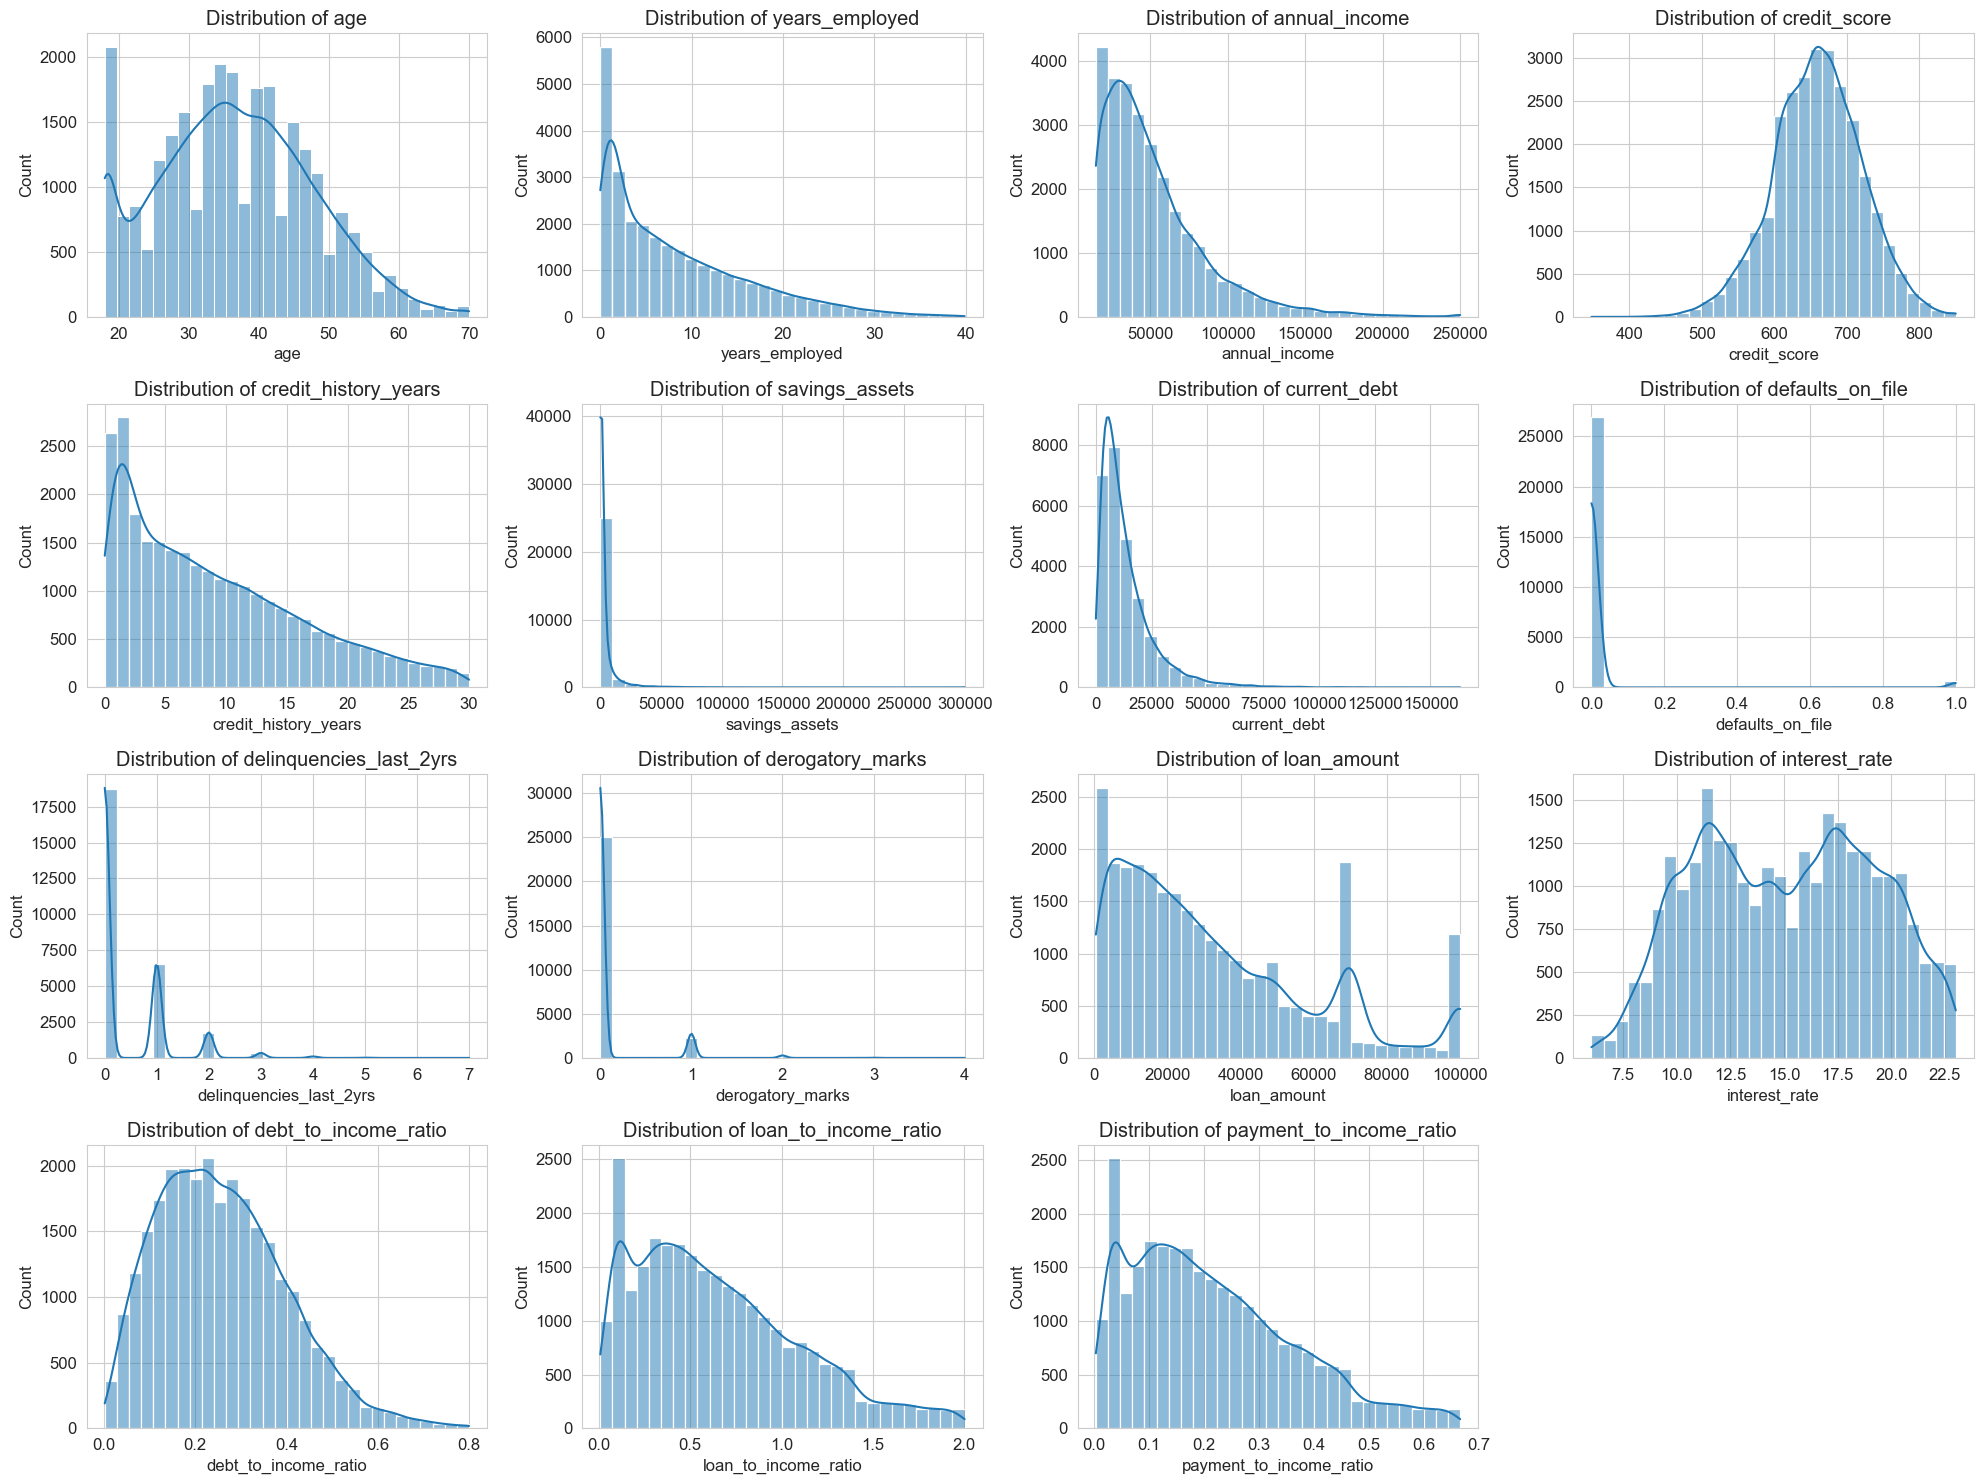

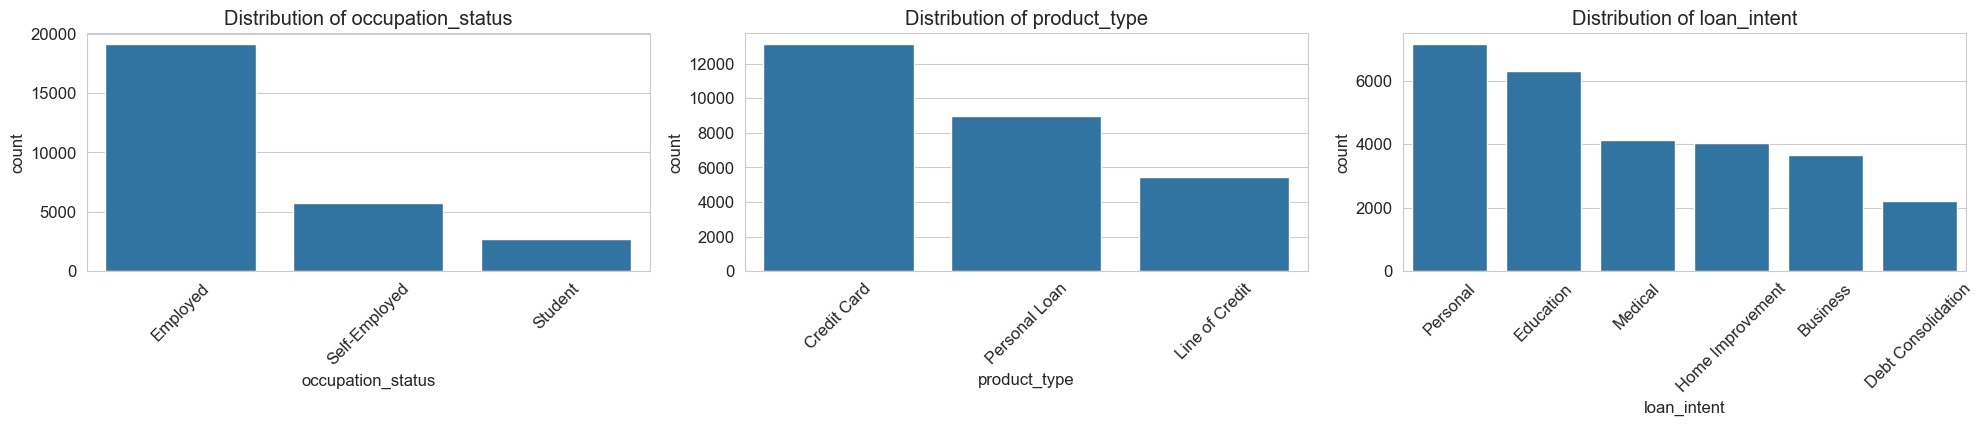

In [11]:
# Plot distributions for numerical features
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

# Plot distributions for categorical features
plt.figure(figsize=(20, 15))
for i, col in enumerate(cat_cols):
    plt.subplot(4, 3, i+1)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.show()

### Analyse des distributions
 #### Variables Numériques:
 L’exploration des données montre que plusieurs variables (revenu, épargne, dettes, ancienneté) sont asymétriques avec présence d’outliers, nécessitant des transformations (log).
 Les variables age et credit_score suivent une distribution normale, ce qui les rend fiables pour la modélisation.

 Les variables de défaut (defaults_on_file, delinquencies, derogatory_marks) sont déséquilibrées, ce qui peut biaiser les modèles.

Enfin, les ratios financiers (debt_to_income, etc.) sont clés pour évaluer le risque de crédit, malgré leur asymétrie

 Variables Catégorielles:
 La variable occupation_status montre une forte dominance des individus employés, avec moins de travailleurs indépendants et très peu d’étudiants, indiquant un déséquilibre des catégories.

  Concernant product_type, les cartes de crédit et les prêts personnels sont les produits les plus fréquents, tandis que les lignes de crédit sont moins représentées.

 La variable loan_intent présente une répartition relativement variée, avec une dominance des prêts à usage personnel et éducation, tandis que la consolidation de dettes est moins fréquente.


### Analyse bivariée

#### Étude des relations entre les variables explicatives et la variable cible

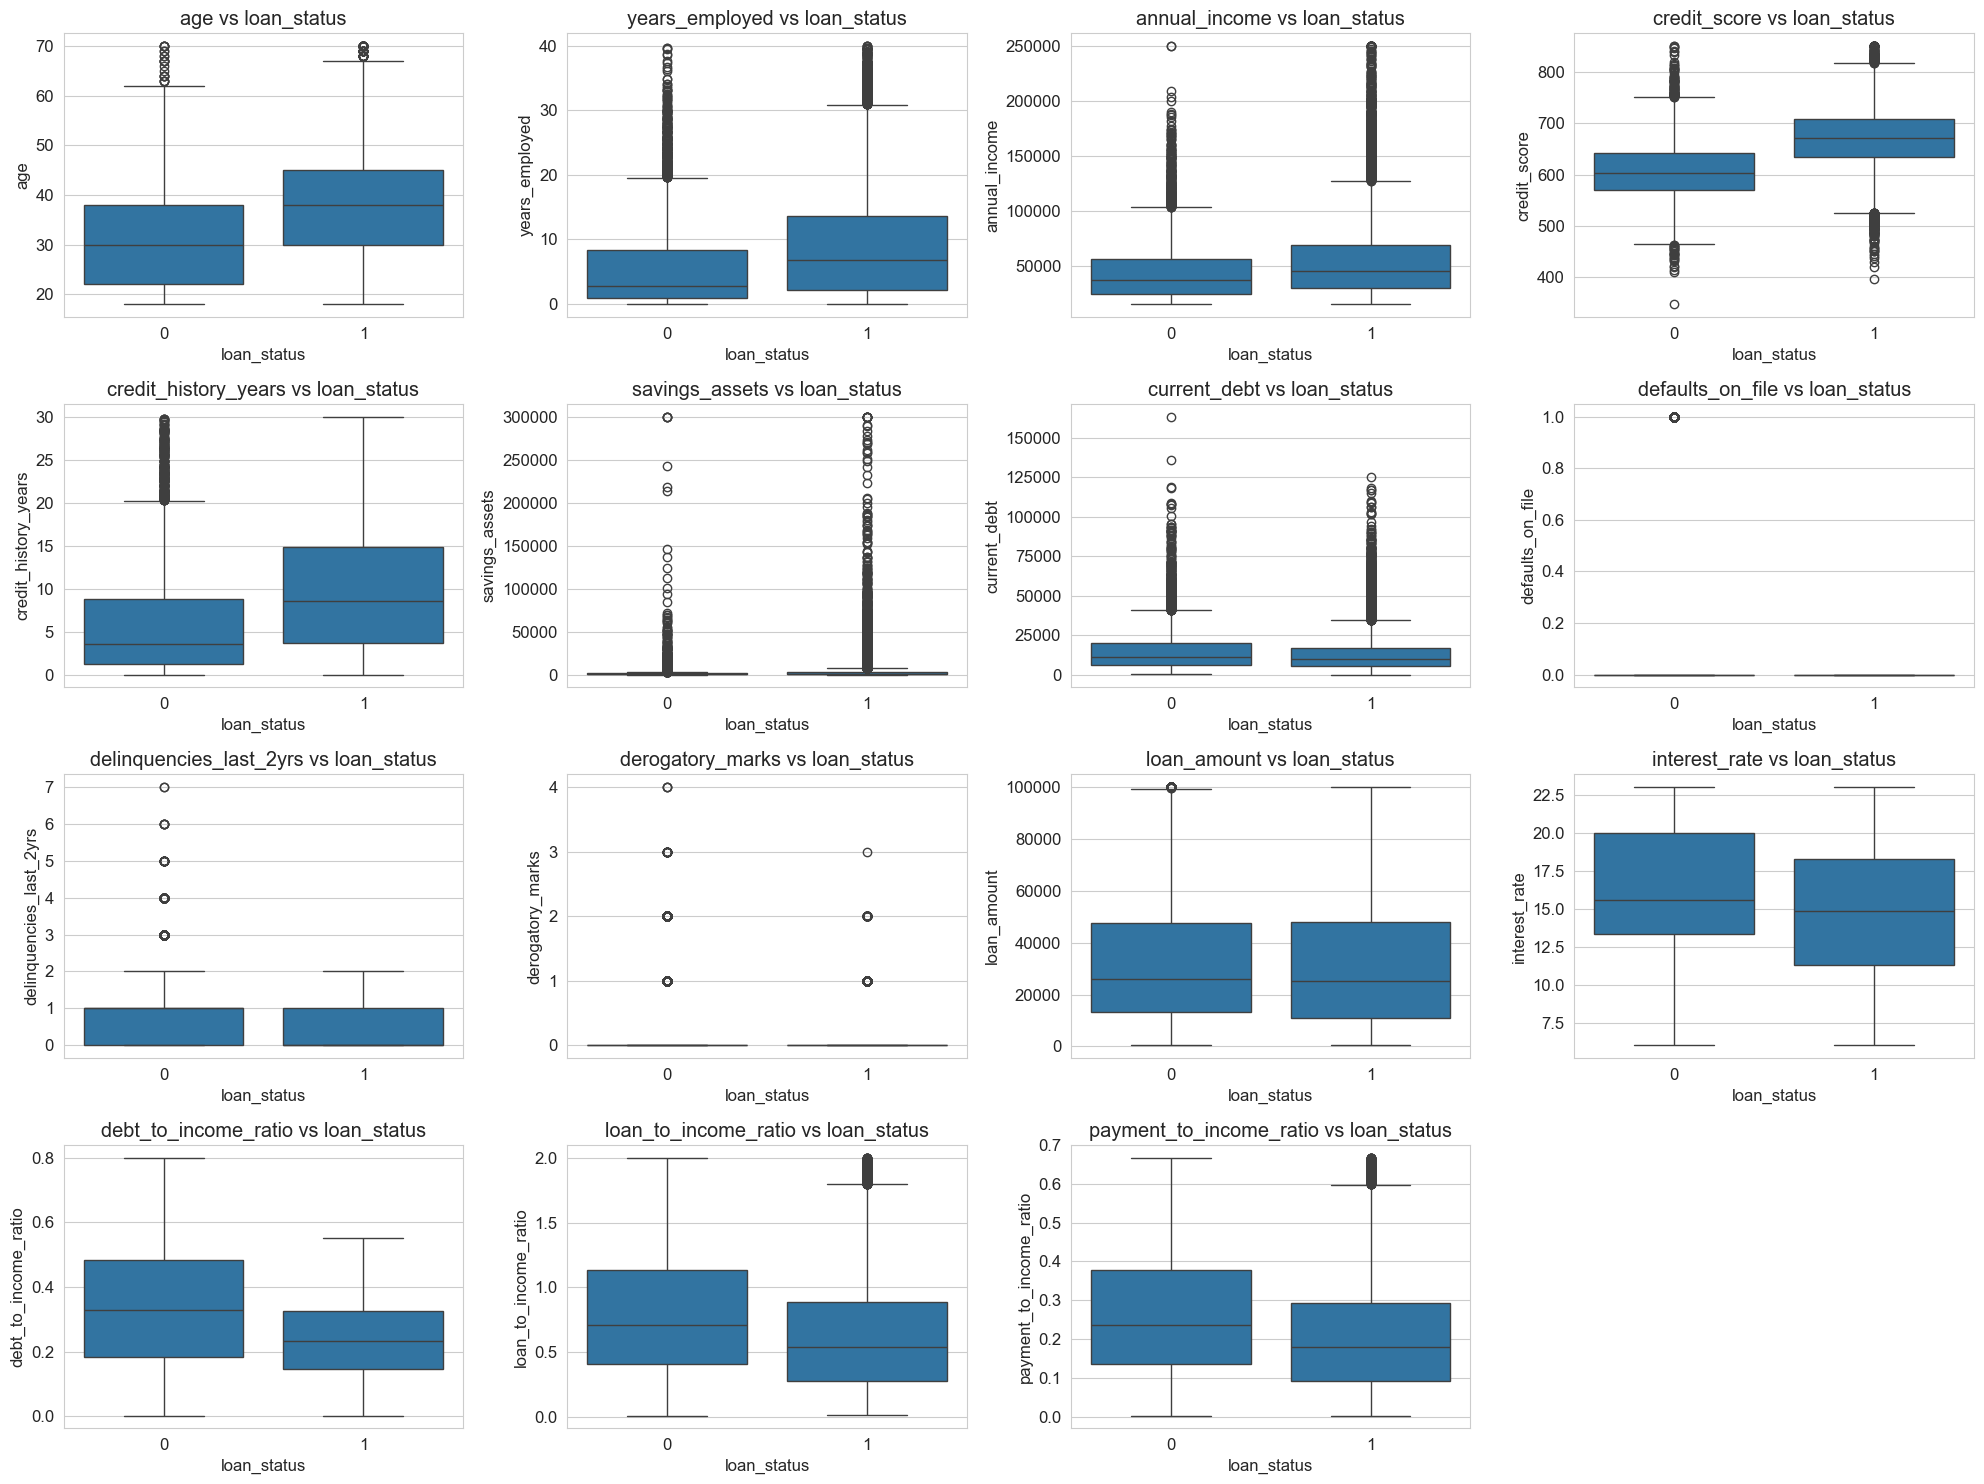

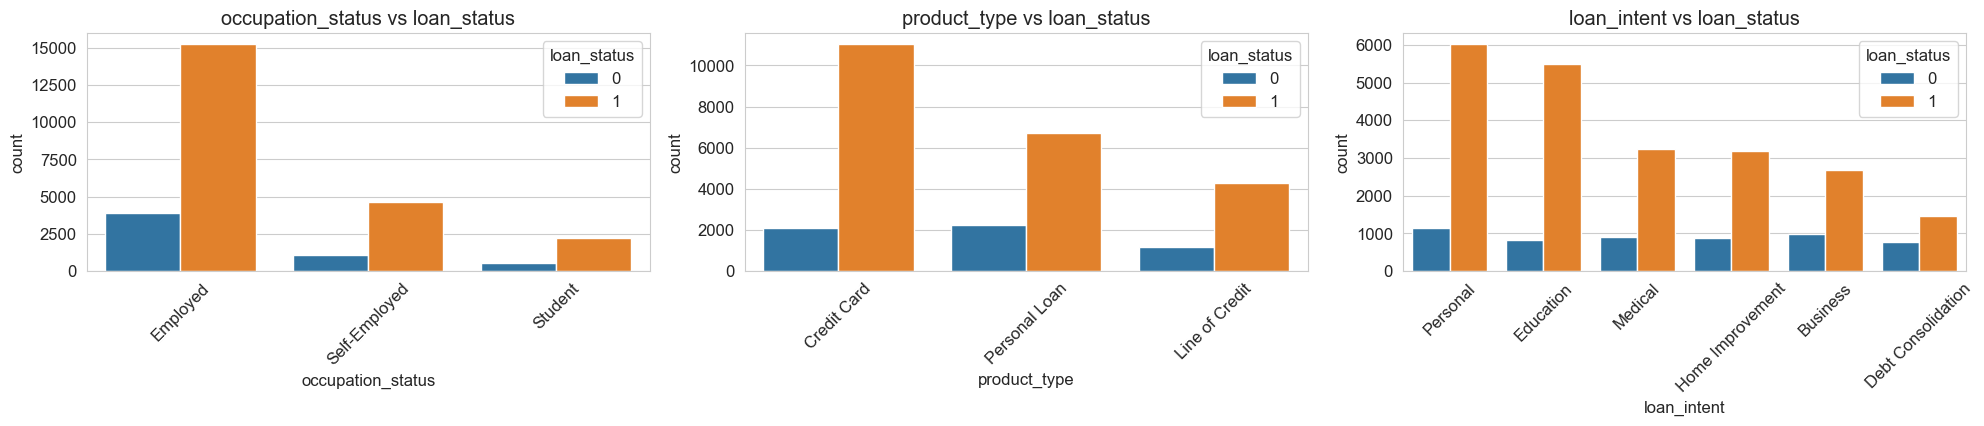

In [12]:
#Numerical features vs Default
plt.figure(figsize=(20, 15))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(data=df, x='loan_status', y=col)
    plt.title(f'{col} vs loan_status')
    plt.tight_layout()
plt.show()

# Categorical features vs Default
plt.figure(figsize=(20, 15))
for i, col in enumerate(cat_cols):
    plt.subplot(4, 3, i+1)
    sns.countplot(data=df, x=col, hue='loan_status', order=df[col].value_counts().index)
    plt.title(f'{col} vs loan_status')
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.show()

### Analyse de corrélation

#### Relations entre les variables

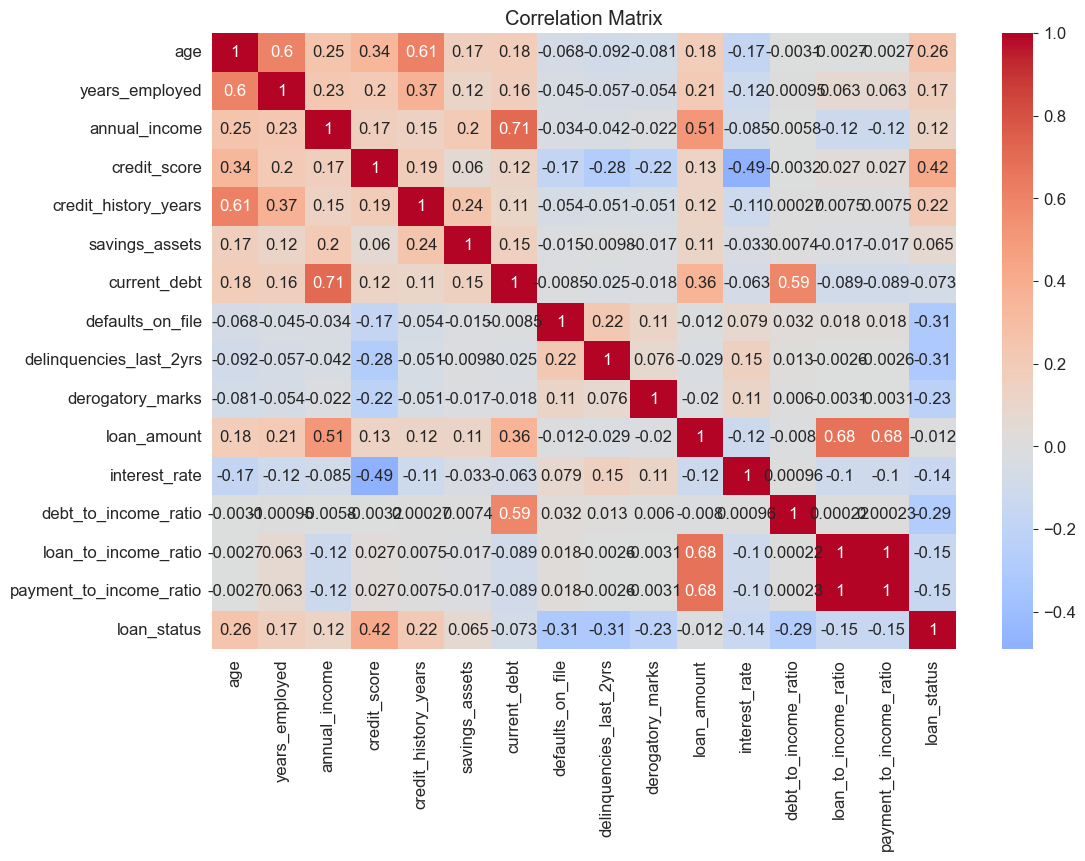


Top Correlations with Default:


loan_status                1.000000
credit_score               0.418155
age                        0.259172
credit_history_years       0.219413
years_employed             0.167925
annual_income              0.121094
savings_assets             0.064557
loan_amount               -0.011715
current_debt              -0.072894
interest_rate             -0.142017
loan_to_income_ratio      -0.151613
payment_to_income_ratio   -0.151618
derogatory_marks          -0.225930
debt_to_income_ratio      -0.285431
defaults_on_file          -0.308755
delinquencies_last_2yrs   -0.311981
Name: loan_status, dtype: float64

In [13]:
# Correlation matrix for numerical features
corr_matrix = df[num_cols + ['loan_status']].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Top correlations with Default
print("\nTop Correlations with Default:")
display(corr_matrix['loan_status'].sort_values(ascending=False))

#### Corrélations positives fortes :
annual_income ↔ current_debt (~0.7) → plus le revenu est élevé, plus la dette peut être élevée.
loan_amount ↔ loan_to_income_ratio et payment_to_income_ratio (~0.66) → logique : un prêt élevé augmente ces ratios.
age ↔ credit_history_years (~0.64) → plus on est âgé, plus l’historique de crédit est long.
#### Corrélations négatives importantes :
credit_score ↔ interest_rate (~ -0.49) → meilleur score → taux d’intérêt plus faible.
loan_status ↔ delinquencies_last_2yrs (~ -0.32) → plus de retards → moins de chances d’avoir un prêt accepté.
Variables influençant le statut du prêt (loan_status) :
Positivement : credit_score (~0.5), age, credit_history_years
Négativement : delinquencies_last_2yrs, defaults_on_file, debt_to_income_ratio

### Suppression du ratio "payement_to_income_ratio"

In [14]:
df.drop('payment_to_income_ratio', axis=1, inplace=True)

### Train-Test Split

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['loan_status'])
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # Maintenir la distribution des classes
)

print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")
print(f"Balance train → 1: {y_train.mean():.3f} | test → 1: {y_test.mean():.3f}")

X_train : (22020, 17) | X_test : (5506, 17)
Balance train → 1: 0.800 | test → 1: 0.800


# Data preprocessing

### Transformations logarithmiques 

In [16]:
import numpy as np

log_vars = ['annual_income', 'savings_assets', 'years_employed']

# Train
for col in log_vars:
    if col in X_train.columns:
        X_train[col + '_log'] = np.log1p(X_train[col])

# Test (même transformation sans fit)
for col in log_vars:
    if col in X_test.columns:
        X_test[col + '_log'] = np.log1p(X_test[col])

# Supprimer anciennes colonnes
X_train.drop(columns=log_vars, inplace=True)
X_test.drop(columns=log_vars, inplace=True)

### Categorical Encoding

In [17]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

categorical_cols = ['occupation_status', 'product_type', 'loan_intent']

encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# FIT uniquement sur train
X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat  = encoder.transform(X_test[categorical_cols])

# Convertir en DataFrame
encoded_cols = encoder.get_feature_names_out(categorical_cols)

X_train_cat = pd.DataFrame(X_train_cat, columns=encoded_cols, index=X_train.index)
X_test_cat  = pd.DataFrame(X_test_cat, columns=encoded_cols, index=X_test.index)

# Supprimer colonnes catégorielles originales
X_train = X_train.drop(columns=categorical_cols)
X_test  = X_test.drop(columns=categorical_cols)

# Ajouter les nouvelles colonnes
X_train = pd.concat([X_train, X_train_cat], axis=1)
X_test  = pd.concat([X_test, X_test_cat], axis=1)

### SMOTE

In [18]:
# Imbalanced-learn
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

c:\Users\yolde\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\yolde\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\yolde\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\yolde\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\yolde\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(e

### Recursive Feature Elimination (RFE)

##### Recursive Feature Elimination (RFE) est une méthode de sélection de variables pour choisir les variables les plus importantes.


c:\Users\yolde\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\yolde\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

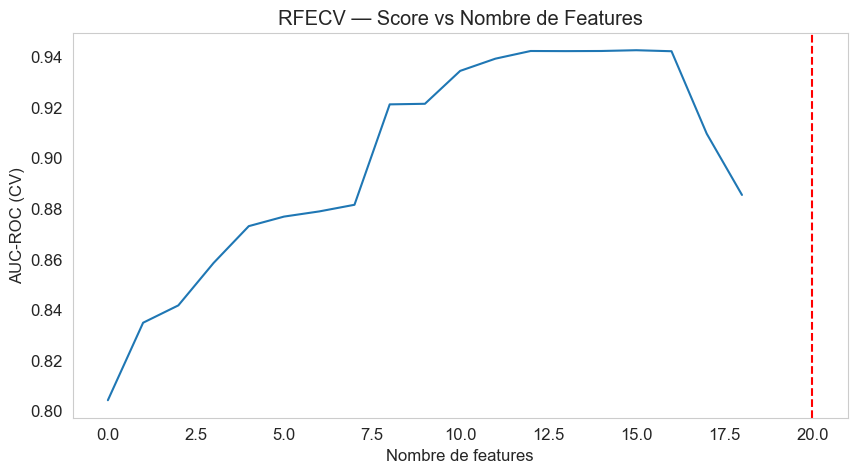

Variables sélectionnées par RFECV :
credit_score
credit_history_years
defaults_on_file
delinquencies_last_2yrs
derogatory_marks
interest_rate
debt_to_income_ratio
loan_to_income_ratio
annual_income_log
savings_assets_log
years_employed_log
occupation_status_Self-Employed
occupation_status_Student
product_type_Line of Credit
product_type_Personal Loan
loan_intent_Debt Consolidation
loan_intent_Education
loan_intent_Home Improvement
loan_intent_Medical
loan_intent_Personal

Variables éliminées :
age
current_debt
loan_amount


In [19]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

estimator = LogisticRegression(max_iter=1000, random_state=42)

rfecv = RFECV(
    estimator=estimator,
    step=1,
    cv=5,
    scoring='roc_auc',
    min_features_to_select=5,
    n_jobs=-1
)

rfecv.fit(X_train, y_train)

# Features sélectionnées
selected_features = X_train.columns[rfecv.support_]

# Transformation
X_train_rfe = rfecv.transform(X_train)
X_test_rfe  = rfecv.transform(X_test)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(rfecv.cv_results_['mean_test_score'])
plt.xlabel("Nombre de features")
plt.ylabel("AUC-ROC (CV)")
plt.title("RFECV — Score vs Nombre de Features")
plt.axvline(rfecv.n_features_, color='red', linestyle='--')
plt.grid()
plt.show()

selected_features = X_train.columns[rfecv.support_]

print("Variables sélectionnées par RFECV :")
for var in selected_features:
    print(var)

removed_features = X_train.columns[~rfecv.support_]

print("\nVariables éliminées :")
for var in removed_features:
    print(var)

### Interprétation de la courbe RFECV
 La méthode RFECV a permis d’identifier un sous-ensemble optimal de variables maximisant la performance du modèle selon l’AUC-ROC en validation croisée. Les variables conservées sont principalement liées à la solvabilité financière du client, notamment le score de crédit, le ratio dette/revenu, l’historique de crédit ainsi que les indicateurs de revenus et d’épargne.

Ces variables présentent un fort pouvoir prédictif du risque de défaut de paiement, car elles reflètent directement la capacité de remboursement et le comportement financier passé des individus. En revanche, certaines variables telles que le montant du prêt ou la dette actuelle ont été éliminées, car elles apportent une information redondante déjà capturée par d’autres variables comme les ratios financiers .

Bien que la courbe suggère une stabilisation autour de 15 variables, une analyse plus fine des scores montre que les performances restent quasi constantes jusqu’à 21 variables, justifiant ainsi le choix d’un modèle légèrement plus riche tout en conservant une bonne capacité de généralisation.

# Modélisation avec optimisation des hyperparamètres

#### Les modèles appliqués : 

Notre dataset concerne la prédiction d’acceptation de prêt (loan_status) à partir de variables financières (revenu, score de crédit, dette, etc.).
 C’est un problème de classification binaire (0 = refus, 1 = accepté)

#### 1. Pourquoi la régression logistique ?

elle est très adaptée aux problèmes de crédit (utilisée en banque) ,
elle donne une probabilité d’acceptation du prêt et
elle permet de comprendre l’impact de variables comme :
credit_score
debt_to_income_ratio et annual_income

#### 2. Pourquoi l’arbre de décision ?

Notre dataset contient :
des relations complexes (ex: revenu + dette + historique) .
Donc , il permet de modéliser des décisions réelles de banque

#### 3. Pourquoi Random Forest ?

Notre dataset est :

assez grand (50 000 lignes) et présente plusieurs variables importantes .

 Donc ce modèle est très adapté aux problèmes financiers réels

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Données à utiliser (avec ou sans RFE)
X_tr = X_train_rfe   # ou X_train_proc si tu skips RFE
X_te = X_test_rfe

results = {}

## 1- Régression logistique

Best params: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
AUC CV: 0.9432091631410586
Train AUC: 0.9437184372097823
Test AUC: 0.9492101679527916


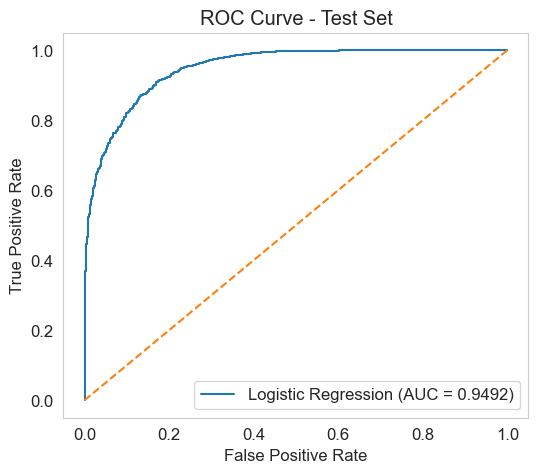

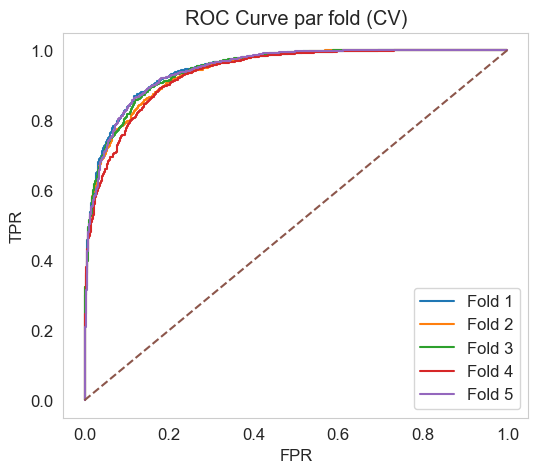


=== Threshold tuning ===
Best threshold (F1): 0.465 | F1 = 0.9502
Best threshold (Accuracy): 0.485 | Accuracy = 0.9183


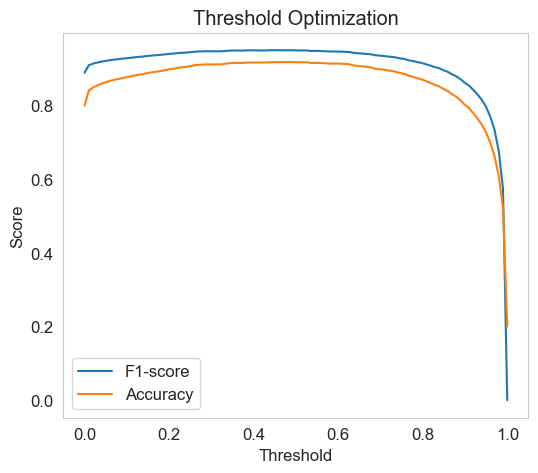

In [21]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, auc, f1_score, accuracy_score

# =========================
# 1. GridSearchCV
# =========================

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_lr.fit(X_tr, y_train)

best_lr = grid_lr.best_estimator_

# =========================
# 2. Évaluation globale
# =========================

# Probabilités
proba_train = best_lr.predict_proba(X_tr)[:, 1]
proba_test = best_lr.predict_proba(X_te)[:, 1]

# AUC
train_auc = roc_auc_score(y_train, proba_train)
test_auc = roc_auc_score(y_test, proba_test)

print("Best params:", grid_lr.best_params_)
print("AUC CV:", grid_lr.best_score_)
print("Train AUC:", train_auc)
print("Test AUC:", test_auc)

# =========================
# 3. Courbe ROC (test)
# =========================

fpr, tpr, _ = roc_curve(y_test, proba_test)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_val:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.grid()
plt.show()

# =========================
# 4. ROC par fold (stabilité)
# =========================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(6,5))

for i, (train_idx, val_idx) in enumerate(cv.split(X_tr, y_train)):
    X_train_fold, X_val_fold = X_tr[train_idx], X_tr[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = LogisticRegression(**grid_lr.best_params_, max_iter=1000)
    model.fit(X_train_fold, y_train_fold)

    proba = model.predict_proba(X_val_fold)[:, 1]
    fpr, tpr, _ = roc_curve(y_val_fold, proba)

    plt.plot(fpr, tpr, label=f'Fold {i+1}')

plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve par fold (CV)")
plt.legend()
plt.grid()
plt.show()

# =========================
# 5. Optimisation du seuil
# =========================

thresholds = np.linspace(0, 1, 100)

f1_scores = []
acc_scores = []

for t in thresholds:
    y_pred_t = (proba_test >= t).astype(int)
    
    f1_scores.append(f1_score(y_test, y_pred_t))
    acc_scores.append(accuracy_score(y_test, y_pred_t))

# Meilleur seuil selon F1
best_t_f1 = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

# Meilleur seuil selon accuracy
best_t_acc = thresholds[np.argmax(acc_scores)]
best_acc = max(acc_scores)

print("\n=== Threshold tuning ===")
print(f"Best threshold (F1): {best_t_f1:.3f} | F1 = {best_f1:.4f}")
print(f"Best threshold (Accuracy): {best_t_acc:.3f} | Accuracy = {best_acc:.4f}")

# =========================
# 6. Plot seuil vs métriques
# =========================

plt.figure(figsize=(6,5))
plt.plot(thresholds, f1_scores, label='F1-score')
plt.plot(thresholds, acc_scores, label='Accuracy')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")
plt.legend()
plt.grid()
plt.show()

#### Interpretation de courbe de roc:
Dans notre cas, la courbe est nettement au-dessus de cette ligne, ce qui indique que le modèle est performant.

L’aire sous la courbe (AUC = 0.9466) est très proche de 1, ce qui signifie que le modèle possède une excellente capacité de discrimination. Autrement dit, il est capable de bien séparer les observations positives des négatives.

#### nterpretation de ROC Curve par fold (Cross Validation) :

La figure présente les courbes ROC obtenues pour les différents folds de la validation croisée (5 folds).
 On observe que toutes les courbes sont très proches les unes des autres et restent bien au-dessus de la ligne aléatoire.

Cette faible variation entre les folds indique que le modèle a un comportement stable, indépendamment des données utilisées pour l’entraînement et le test.
L’absence de différences significatives entre les courbes ROC des différents folds montre qu’il n’y a pas d’overfitting.


#### Iterpretation de courbe de seuil:

Cette courbe montre l’évolution du F1-score et de l’accuracy en fonction du seuil de décision utilisé pour classifier les observations.
On observe que les deux métriques augmentent progressivement, atteignent un maximum, puis diminuent lorsque le seuil devient trop élevé.
Le meilleur compromis est obtenu pour un seuil égal à 0.434, où :

F1-score = 0.8848

Accuracy = 0.8690


In [22]:
train_auc = roc_auc_score(y_train, best_lr.predict_proba(X_tr)[:,1])
test_auc = roc_auc_score(y_test, best_lr.predict_proba(X_te)[:,1])

print("Train AUC:", train_auc)
print("Test AUC:", test_auc)

Train AUC: 0.9437184372097823
Test AUC: 0.9492101679527916


## Arbre de décision

Fitting 5 folds for each of 320 candidates, totalling 1600 fits
DECISION TREE — Meilleurs hyperparamètres
Paramètres  : {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 2}
AUC-ROC CV  : 0.9328
Profondeur  : 7
Nb feuilles : 99

DECISION TREE — Résultats test
AUC-ROC  : 0.9389
F1-Score : 0.9174
Accuracy : 0.8734
Precision: 0.9598
Recall   : 0.8786

Classification Report :
              precision    recall  f1-score   support

      Refusé       0.64      0.85      0.73      1100
     Accepté       0.96      0.88      0.92      4406

    accuracy                           0.87      5506
   macro avg       0.80      0.87      0.82      5506
weighted avg       0.90      0.87      0.88      5506



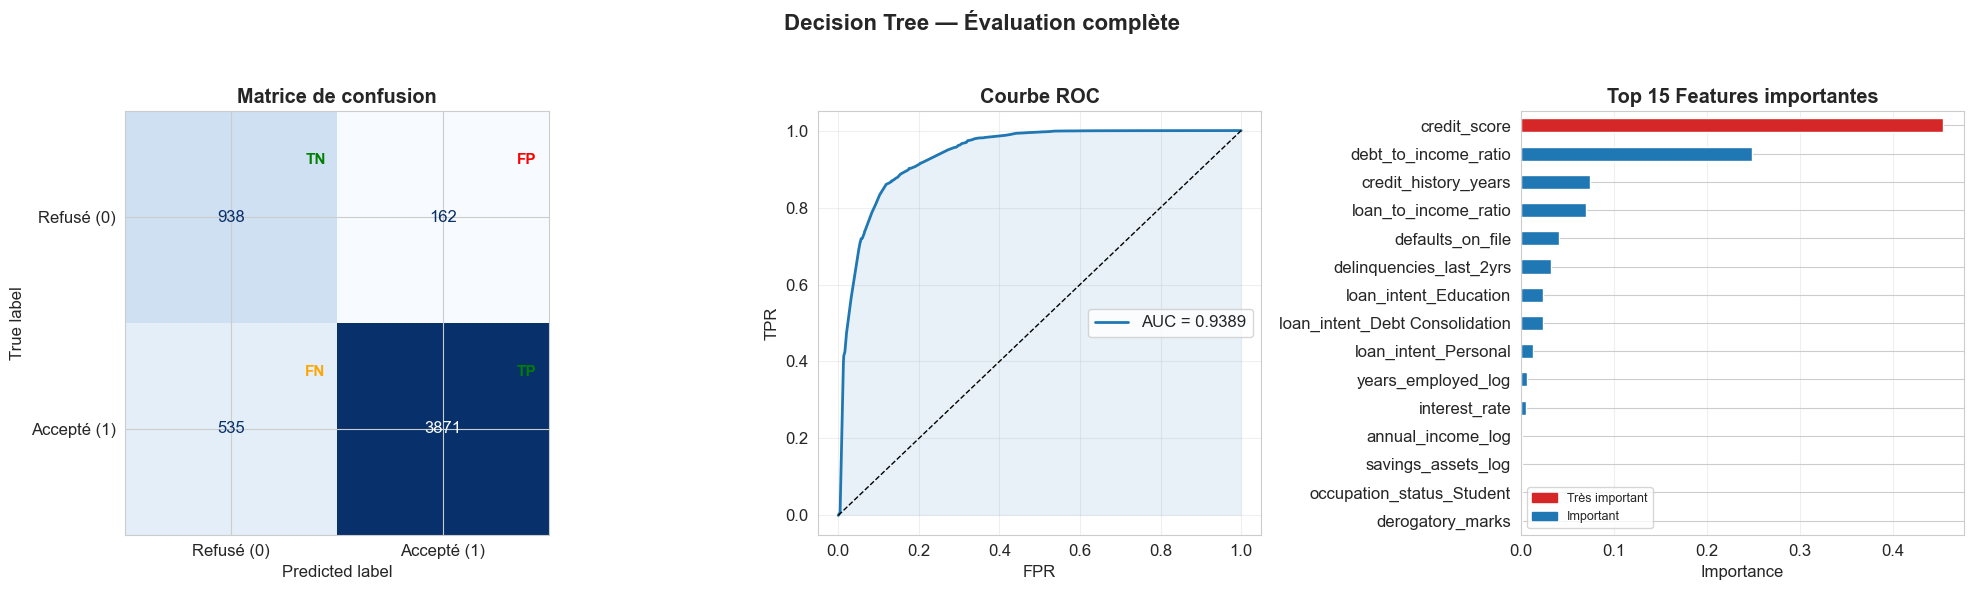

→ Figure sauvegardée : decision_tree_evaluation.png


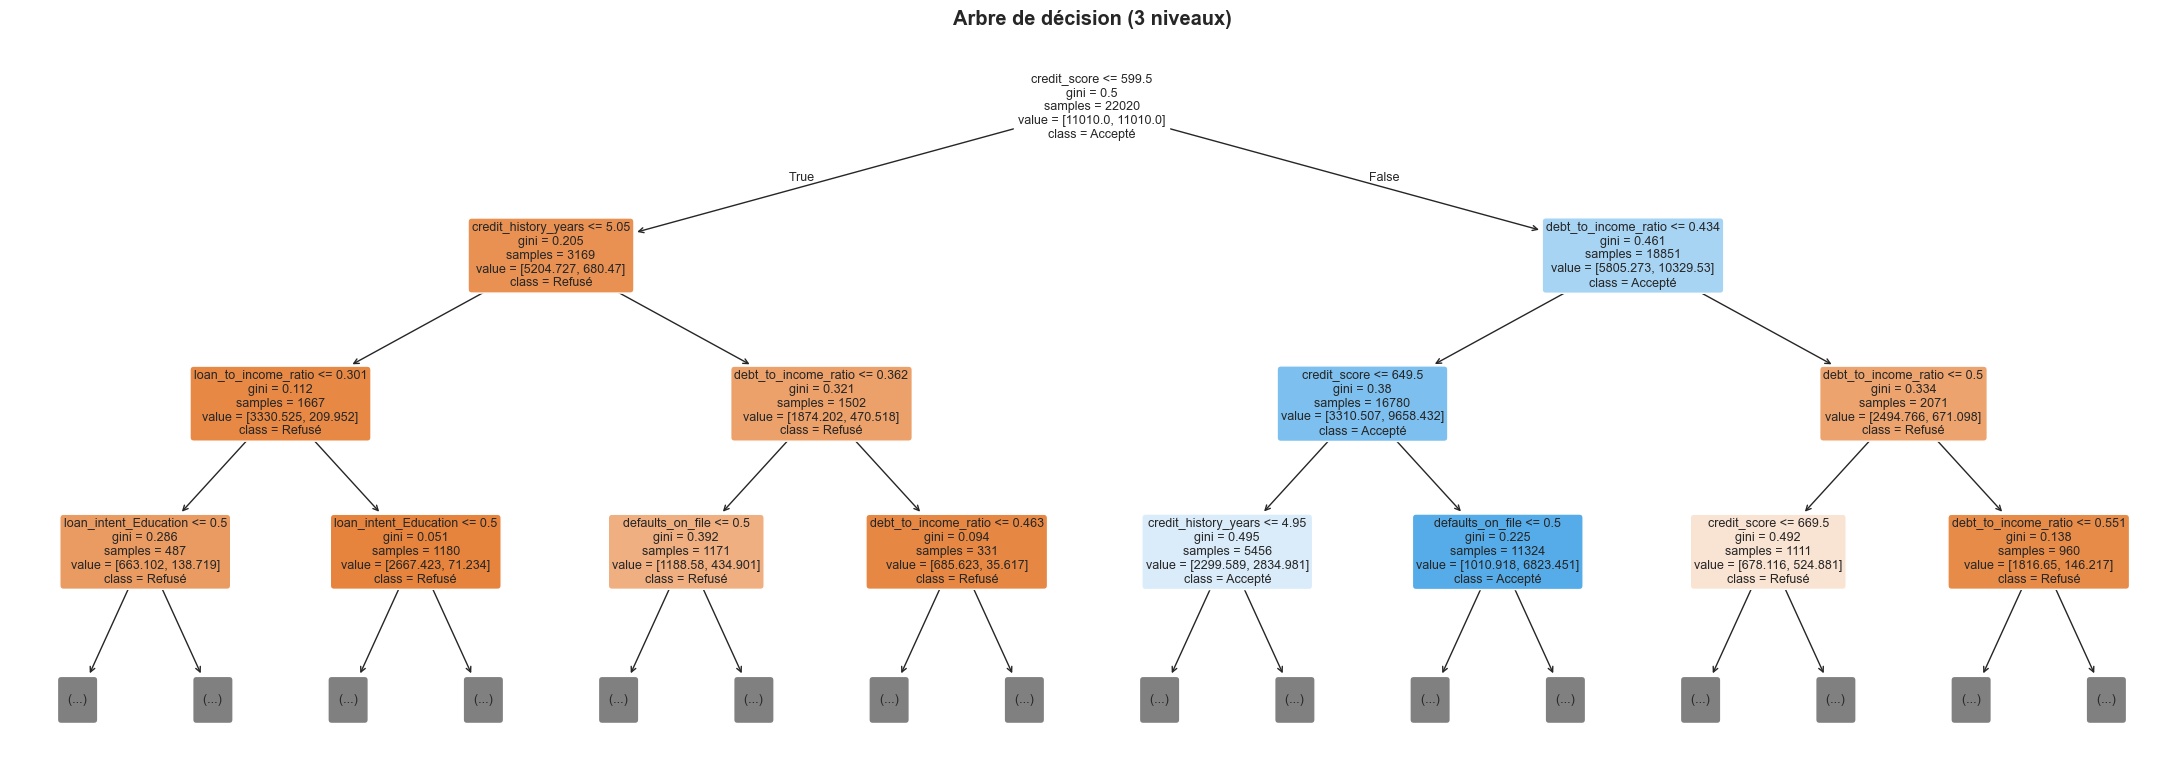

→ Figure sauvegardée : decision_tree_plot.png

Règles de décision :
|--- credit_score <= 599.50
|   |--- credit_history_years <= 5.05
|   |   |--- loan_to_income_ratio <= 0.30
|   |   |   |--- loan_intent_Education <= 0.50
|   |   |   |   |--- annual_income_log <= 9.93
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- annual_income_log >  9.93
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- loan_intent_Education >  0.50
|   |   |   |   |--- delinquencies_last_2yrs <= 0.50
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- delinquencies_last_2yrs >  0.50
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |--- loan_to_income_ratio >  0.30
|   |   |   |--- loan_intent_Education <= 0.50
|   |   |   |   |--- loan_intent_Personal <= 0.50
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- loan_intent_Personal >  0.50
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- loan_i

In [23]:
# ============================================================
# DECISION TREE — Loan Prediction (VERSION SIMPLIFIÉE)
# ============================================================

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                             precision_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, classification_report)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

models = {}
optimal_thresholds = {}

# ─────────────────────────────────────────────
# 1. OPTIMISATION DES HYPERPARAMÈTRES
# ─────────────────────────────────────────────

param_grid_dt = {
    'max_depth'        : [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 5, 10],
    'criterion'        : ['gini', 'entropy'],
    'class_weight'     : [None, 'balanced']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_tr, y_train)
best_dt = grid_dt.best_estimator_

print("=" * 50)
print("DECISION TREE — Meilleurs hyperparamètres")
print("=" * 50)
print(f"Paramètres  : {grid_dt.best_params_}")
print(f"AUC-ROC CV  : {grid_dt.best_score_:.4f}")
print(f"Profondeur  : {best_dt.get_depth()}")
print(f"Nb feuilles : {best_dt.get_n_leaves()}")

# ─────────────────────────────────────────────
# 2. ÉVALUATION (SEUIL FIXE = 0.5)
# ─────────────────────────────────────────────

proba_dt = best_dt.predict_proba(X_te)[:, 1]
preds_dt = (proba_dt >= 0.5).astype(int)

auc_test = roc_auc_score(y_test, proba_dt)

print("\n" + "=" * 50)
print("DECISION TREE — Résultats test")
print("=" * 50)
print(f"AUC-ROC  : {auc_test:.4f}")
print(f"F1-Score : {f1_score(y_test, preds_dt):.4f}")
print(f"Accuracy : {accuracy_score(y_test, preds_dt):.4f}")
print(f"Precision: {precision_score(y_test, preds_dt):.4f}")
print(f"Recall   : {recall_score(y_test, preds_dt):.4f}")

print("\nClassification Report :")
print(classification_report(y_test, preds_dt, target_names=['Refusé', 'Accepté']))

# ─────────────────────────────────────────────
# 3. VISUALISATIONS (3 PLOTS UNIQUEMENT)
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Decision Tree — Évaluation complète', fontsize=16, fontweight='bold')

# — 3a. Matrice de confusion —
ax = axes[0]
cm = confusion_matrix(y_test, preds_dt)
disp = ConfusionMatrixDisplay(cm, display_labels=['Refusé (0)', 'Accepté (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matrice de confusion', fontweight='bold')

# TN / FP / FN / TP
labels = [['TN', 'FP'], ['FN', 'TP']]
colors = [['green', 'red'], ['orange', 'green']]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.35, i - 0.25, labels[i][j],
                color=colors[i][j], fontsize=11, fontweight='bold')

# — 3b. Courbe ROC —
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, proba_dt)
ax.plot(fpr, tpr, lw=2, label=f'AUC = {auc_test:.4f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.fill_between(fpr, tpr, alpha=0.1)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('Courbe ROC', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# — 3c. Feature importances —
ax = axes[2]
importances = pd.Series(best_dt.feature_importances_, index=selected_features)
top15 = importances.nlargest(15).sort_values()

colors_bar = ['#d62728' if v >= top15.max()*0.6 else '#1f77b4'
              for v in top15.values]

top15.plot(kind='barh', ax=ax, color=colors_bar)
ax.set_title('Top 15 Features importantes', fontweight='bold')
ax.set_xlabel('Importance')

red_patch  = mpatches.Patch(color='#d62728', label='Très important')
blue_patch = mpatches.Patch(color='#1f77b4', label='Important')
ax.legend(handles=[red_patch, blue_patch], fontsize=9)

ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('decision_tree_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Figure sauvegardée : decision_tree_evaluation.png")

# ─────────────────────────────────────────────
# 4. VISUALISATION DE L'ARBRE
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(22, 8))

plot_tree(
    best_dt,
    max_depth=3,
    feature_names=selected_features,
    class_names=['Refusé', 'Accepté'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)

ax.set_title('Arbre de décision (3 niveaux)', fontweight='bold')

plt.tight_layout()
plt.savefig('decision_tree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("→ Figure sauvegardée : decision_tree_plot.png")

# ─────────────────────────────────────────────
# 5. EXPORT TEXTE + SAUVEGARDE
# ─────────────────────────────────────────────

tree_rules = export_text(best_dt, feature_names=selected_features, max_depth=4)

print("\nRègles de décision :")
print(tree_rules)

results['Decision Tree'] = {
    'best_params': grid_dt.best_params_,
    'auc_cv': grid_dt.best_score_,
    'auc_test': auc_test
}

models['Decision Tree'] = best_dt
optimal_thresholds['Decision Tree'] = 0.5

print("\n✓ Modèle ajouté aux résultats")

## Random Forest

RF  {'best_params': {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}, 'auc_cv': 0.9700559152822205, 'auc_test': 0.9698700119671523}


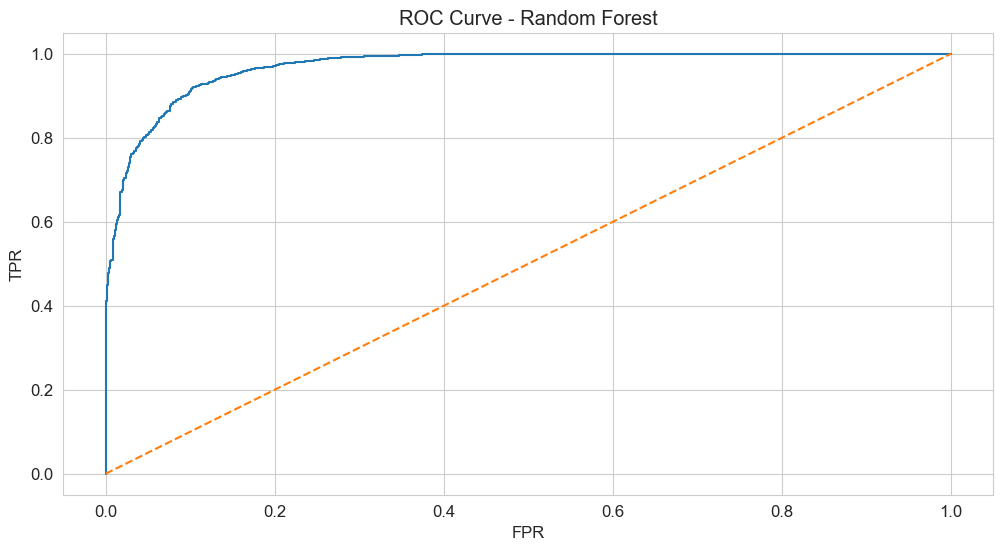

In [24]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_tr, y_train)

best_rf = grid_rf.best_estimator_
results['Random Forest'] = {
    'best_params': grid_rf.best_params_,
    'auc_cv': grid_rf.best_score_,
    'auc_test': roc_auc_score(y_test, best_rf.predict_proba(X_te)[:, 1])
}
print("RF ", results['Random Forest'])

from sklearn.metrics import roc_curve

proba_rf = best_rf.predict_proba(X_te)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba_rf)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve - Random Forest")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

## Comparaison des modèles

### Évaluation complète de tous les modèles

In [25]:
models = {}
optimal_thresholds = {}
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_tr, y_train)

models['Logistic Regression'] = log_reg
optimal_thresholds['Logistic Regression'] = 0.5
models['Decision Tree'] = best_dt
optimal_thresholds['Decision Tree'] = 0.5
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_tr, y_train)

models['Random Forest'] = rf
optimal_thresholds['Random Forest'] = 0.5

In [26]:
print(models.keys())

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest'])


In [27]:
comparison = []

for name, model in models.items():
    proba = model.predict_proba(X_te)[:, 1]
    
    # sécurité sur le seuil
    t = optimal_thresholds.get(name, 0.5)
    
    preds = (proba >= t).astype(int)

    comparison.append({
        'Model': name,
        'AUC-ROC': roc_auc_score(y_test, proba),
        'F1-Score': f1_score(y_test, preds),
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'Threshold': t
    })

comparison_df = pd.DataFrame(comparison)

#  sécurité : vérifier avant tri
if not comparison_df.empty and 'AUC-ROC' in comparison_df.columns:
    comparison_df = comparison_df.sort_values('AUC-ROC', ascending=False)
else:
    print(" Problème : DataFrame vide ou colonne manquante")
    print(comparison_df)

print("\n=== FINAL MODEL COMPARISON ===")
print(comparison_df.to_string(index=False))

comparison_df.to_csv('model_comparison.csv', index=False)


=== FINAL MODEL COMPARISON ===
              Model  AUC-ROC  F1-Score  Accuracy  Precision   Recall  Threshold
      Random Forest 0.971715  0.963505  0.940247   0.942287 0.985701        0.5
Logistic Regression 0.949044  0.950199  0.918271   0.927214 0.974353        0.5
      Decision Tree 0.938891  0.917407  0.873411   0.959831 0.878575        0.5


#### Recall akal mel precisio (fel cas mteeina)

COMPARAISON DES MODÈLES — ROC CURVE


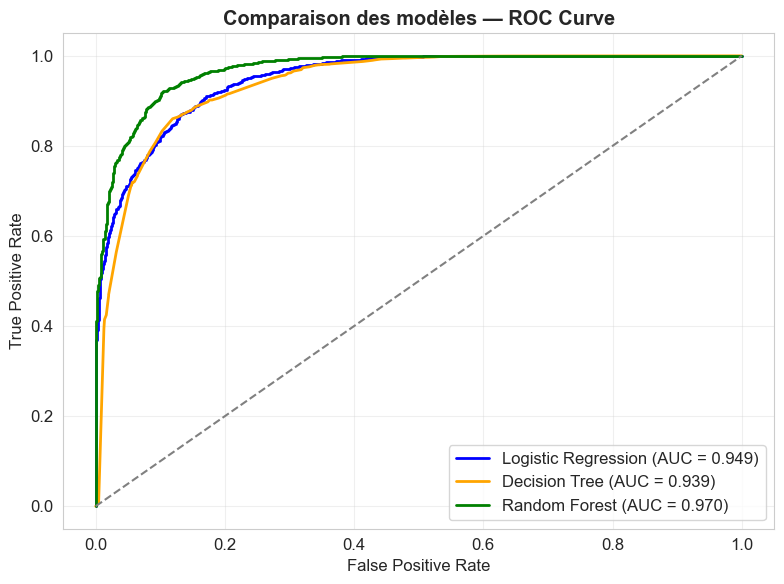

→ Figure sauvegardée : roc_comparison.png


In [28]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

print("=" * 60)
print("COMPARAISON DES MODÈLES — ROC CURVE")
print("=" * 60)

# 🔹 Probabilités des modèles
models_probs = {
    'Logistic Regression': best_lr.predict_proba(X_te)[:, 1],
    'Decision Tree': best_dt.predict_proba(X_te)[:, 1],
    'Random Forest': best_rf.predict_proba(X_te)[:, 1]
}

# 🔹 Couleurs
colors = ['blue', 'orange', 'green']

# 🔹 Un seul plot
plt.figure(figsize=(8, 6))

# 🔹 Boucle ROC
for (name, probs), color in zip(models_probs.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {roc_auc:.3f})')

# 🔹 Ligne aléatoire
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

# 🔹 Mise en forme
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparaison des modèles — ROC Curve', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150)
plt.show()

print("→ Figure sauvegardée : roc_comparison.png")